# Semantic Benchmark Python Small Graph Inspection

Separates missing/empty graph layers from genuinely small non-empty graph layers, then renders code plus graph layers for the small non-empty examples.


In [25]:
from pathlib import Path
import html
import json
import pickle
import random
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import HTML, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "spectral_code").exists() and (candidate / "pipelines").exists():
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.evaluation.notebook_helpers import semantic_spec

LANGUAGE = "python"
DISPLAY_LANGUAGE = "Python"
GRAPH_TYPES = ['ast', 'cfg', 'ddg', 'cpg']
PRIMARY_GRAPH_TYPE = "cpg"

spec = semantic_spec(LANGUAGE)
DATA_DIR = spec.data_dir
OUTPUT_ROOT = spec.output_root
REPORTS_DIR = OUTPUT_ROOT / "reports"
GRAPH_MANIFEST_PATH = OUTPUT_ROOT / "clean_graphs" / "graph_shards_manifest.json"
SPECTRAL_MANIFEST_PATH = OUTPUT_ROOT / "spectral_features" / "spectral_features_manifest.json"
PIPELINE_TIMINGS_PATH = OUTPUT_ROOT / "pipeline_timings.json"

print("Project root:", PROJECT_ROOT)
print("Prepared data:", DATA_DIR)
print("Output root:", OUTPUT_ROOT)


Project root: c:\Users\koush\PyProjects\spectrals\Spectral-Software
Prepared data: C:\Users\koush\PyProjects\spectrals\data\semantic_benchmark_prepared\python
Output root: C:\Users\koush\PyProjects\spectrals\outputs\semantic_benchmark\python


In [26]:
def load_code_for_ids(path: Path, wanted_ids: set[str]) -> dict[str, str]:
    code_map = {}
    if not path.exists():
        return code_map
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            method_id = str(row["idx"])
            if method_id in wanted_ids:
                code_map[method_id] = row.get("func", "")
                if len(code_map) == len(wanted_ids):
                    break
    return code_map


def load_graph_manifest() -> dict:
    if not GRAPH_MANIFEST_PATH.exists():
        raise FileNotFoundError(f"Graph manifest not found: {GRAPH_MANIFEST_PATH}. Run ../run_pipeline/02_extract_graphs.py first.")
    return json.loads(GRAPH_MANIFEST_PATH.read_text(encoding="utf-8"))


def load_graphs_for_ids(manifest: dict, wanted_ids: set[str]) -> dict[str, dict[str, nx.DiGraph]]:
    graphs = {}
    for shard_path in manifest.get("shards", []):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)
        for method_id in list(wanted_ids - set(graphs)):
            if method_id in shard:
                graphs[method_id] = shard[method_id]
        if len(graphs) == len(wanted_ids):
            break
    return graphs


def load_spectral_features_for_ids(manifest_path: Path, wanted_ids: set[str]) -> dict[str, dict]:
    if not manifest_path.exists():
        return {}
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    features = {}
    for shard_path in manifest.get("shards", []):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)
        for method_id in list(wanted_ids - set(features)):
            if method_id in shard:
                features[method_id] = shard[method_id]
        if len(features) == len(wanted_ids):
            break
    return features


def draw_graph(graph: nx.DiGraph | None, title: str, ax, max_nodes: int = 100) -> None:
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    if graph is None or graph.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "empty", ha="center", va="center")
        return
    graph = nx.DiGraph(graph)
    shown = graph if graph.number_of_nodes() <= max_nodes else graph.subgraph(list(graph.nodes())[:max_nodes]).copy()
    pos = nx.spring_layout(shown, seed=42)
    nx.draw_networkx_edges(shown, pos, ax=ax, arrows=False, alpha=0.25, width=0.8)
    nx.draw_networkx_nodes(shown, pos, ax=ax, node_size=22, alpha=0.85)
    ax.text(0.01, 0.02, f"{graph.number_of_nodes()} nodes / {graph.number_of_edges()} edges", transform=ax.transAxes, fontsize=7)


def eigenvalues_for(spectral_map: dict, method_id: str, graph_type: str) -> np.ndarray:
    values = spectral_map.get(str(method_id), {}).get(graph_type, {}).get("eigenvalues", [])
    values = np.asarray(values, dtype=np.float64)
    return values[np.isfinite(values)]


def draw_eigenvalues(spectral_map: dict, method_id: str, graph_type: str, ax) -> None:
    values = eigenvalues_for(spectral_map, method_id, graph_type)
    ax.set_title(f"{graph_type.upper()} eigenvalues", fontsize=9)
    if values.size == 0:
        ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    ax.plot(np.arange(1, values.size + 1), np.sort(values), linewidth=1.2)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=8)


def render_code(method_id: str, code_map: dict[str, str], title: str) -> None:
    display(HTML(f"""
    <div style="border:1px solid #d0d7de;border-radius:6px;overflow:hidden;margin:10px 0;">
      <div style="padding:6px 10px;background:#f6f8fa;font-family:system-ui,sans-serif;font-size:13px;">{html.escape(title)} - id {html.escape(str(method_id))}</div>
      <pre style="margin:0;padding:12px;overflow-x:auto;white-space:pre-wrap;font-size:12px;line-height:1.35;max-height:460px;">{html.escape(code_map.get(str(method_id), ""))}</pre>
    </div>
    """))


def render_code_pair(left_id: str, right_id: str, code_map: dict[str, str], title: str) -> None:
    display(HTML(f"""
    <h3>{html.escape(title)}</h3>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;align-items:start;">
      <div><b>left id: {html.escape(str(left_id))}</b><pre style="white-space:pre-wrap;font-size:12px;line-height:1.35;border:1px solid #d0d7de;padding:10px;border-radius:6px;max-height:460px;overflow:auto;">{html.escape(code_map.get(str(left_id), ""))}</pre></div>
      <div><b>right id: {html.escape(str(right_id))}</b><pre style="white-space:pre-wrap;font-size:12px;line-height:1.35;border:1px solid #d0d7de;padding:10px;border-radius:6px;max-height:460px;overflow:auto;">{html.escape(code_map.get(str(right_id), ""))}</pre></div>
    </div>
    """))


Graph methods: 2000


,graph_type,status,layers,unique_methods,avg_nodes,avg_edges,avg_code_lines,avg_ast_nodes,total_methods,unique_method_fraction
0,ast,small_nonempty,1,1,6.000000,5.000000,6.000000,6.000000,2000,0.0005
1,cfg,small_nonempty,203,203,4.891626,3.911330,5.970443,81.187192,2000,0.1015
2,cfg,suspicious_small,30,30,9.100000,8.466667,15.600000,151.000000,2000,0.0150
3,cpg,small_nonempty,1,1,6.000000,8.000000,6.000000,6.000000,2000,0.0005
4,ddg,small_nonempty,290,290,4.300000,4.503448,5.900000,95.182759,2000,0.1450
5,ddg,suspicious_small,9,9,9.777778,13.222222,15.333333,184.000000,2000,0.0045


,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
303,30962,ast,small_nonempty,6,5,6,6,193,6
167,30550,cfg,small_nonempty,4,3,11,11,320,8
391,31284,cfg,small_nonempty,5,4,41,10,256,7
505,31762,cfg,small_nonempty,4,3,37,9,186,6
7,29879,cfg,small_nonempty,5,4,33,9,352,6
...,...,...,...,...,...,...,...,...,...
180,30574,cfg,small_nonempty,4,3,11,6,125,6
184,30600,cfg,small_nonempty,4,3,105,6,285,6
197,30651,cfg,small_nonempty,4,3,55,6,197,6
215,30673,cfg,small_nonempty,4,3,55,6,283,6


,metric,value
0,dot_missing_ast,136
1,dot_missing_cfg,2
2,dot_missing_ddg,2
3,fallback_graph_layers_pipeline01,1385
4,python_ast_fallback_layers_pipeline01,136
5,python_cfg_fallback_layers_pipeline01,553
6,python_ddg_fallback_layers_pipeline01,696
7,skipped_graph_layers_pipeline01,0
8,total_methods,2000


Example method ids: ['29954', '30057', '30158', '30174', '30185', '30187', '30189', '30201']
Suspicious small CFG/DDG layers are code-size-aware; missing layers are reported separately.
Loaded examples: 8 8


,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
25,29954,ddg,suspicious_small,4,4,212,8,125,6


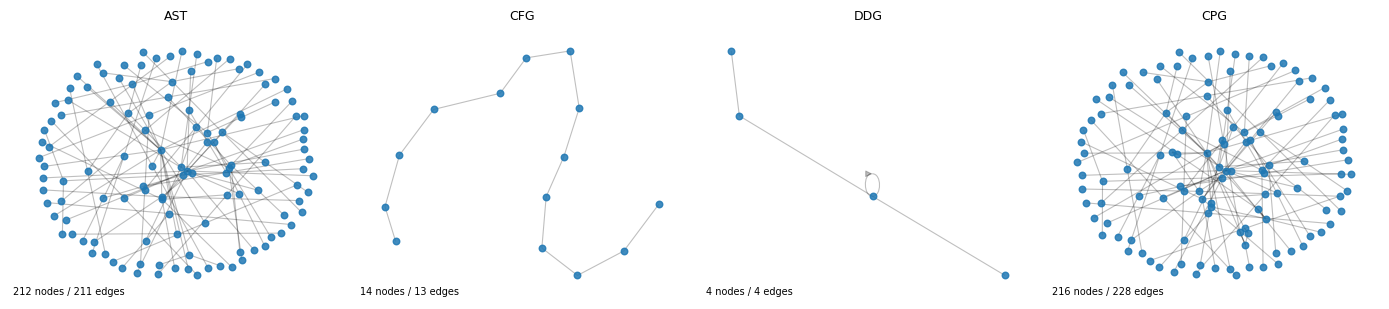

,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
41,30057,ddg,suspicious_small,7,10,118,10,153,7


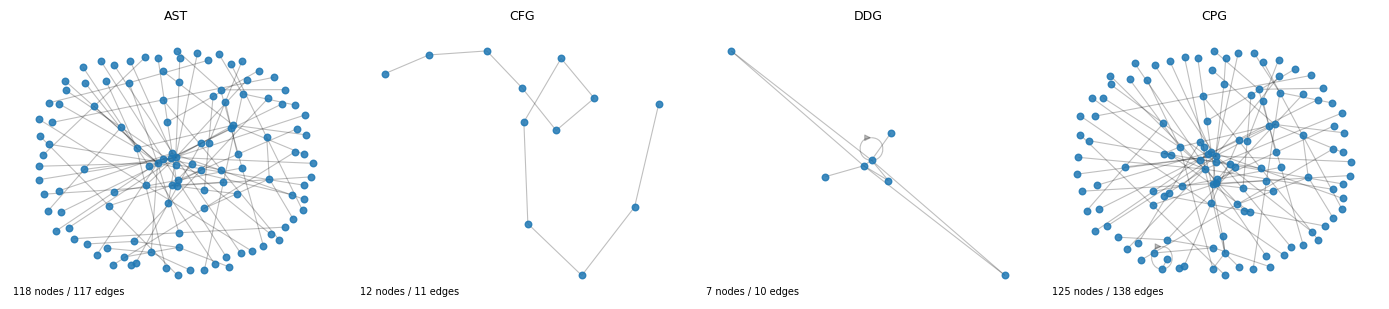

,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
68,30158,cfg,suspicious_small,16,15,173,23,888,17


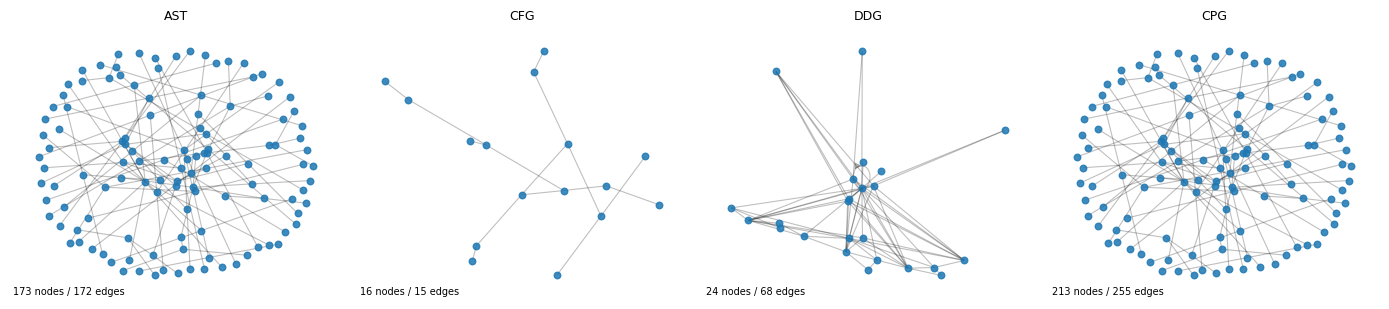

,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
79,30174,cfg,suspicious_small,6,5,80,8,301,6


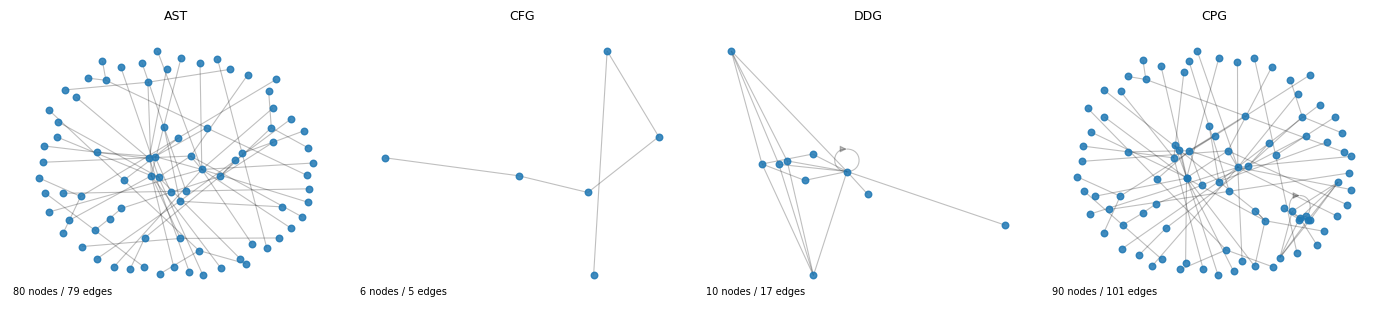

,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
84,30185,cfg,suspicious_small,8,7,330,13,287,9


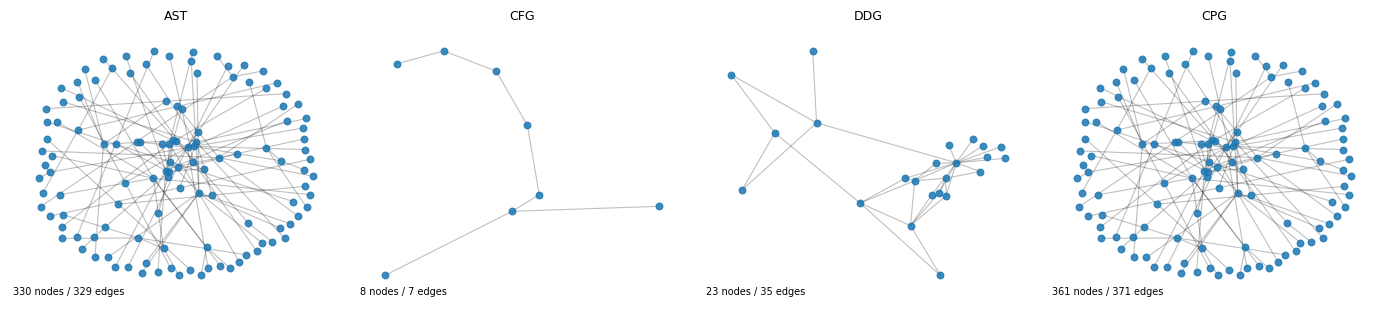

,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
85,30187,cfg,suspicious_small,8,7,353,13,287,9


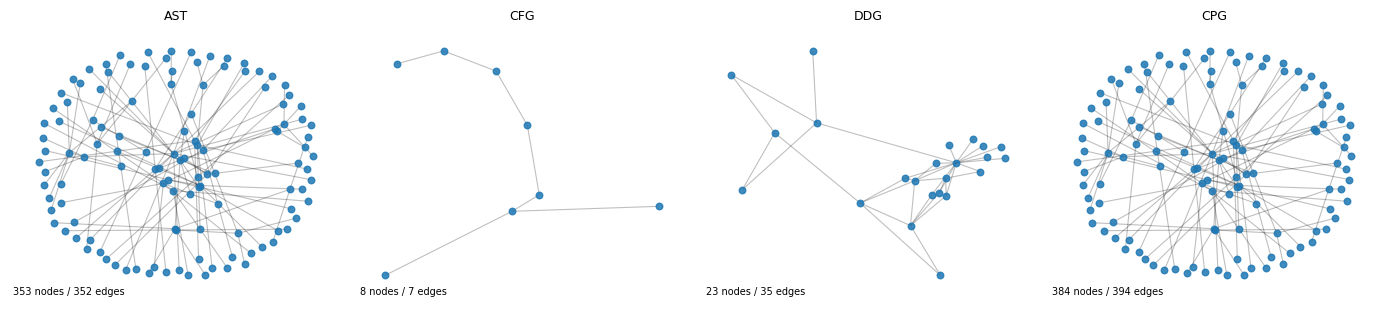

,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
86,30189,cfg,suspicious_small,6,5,143,10,213,7


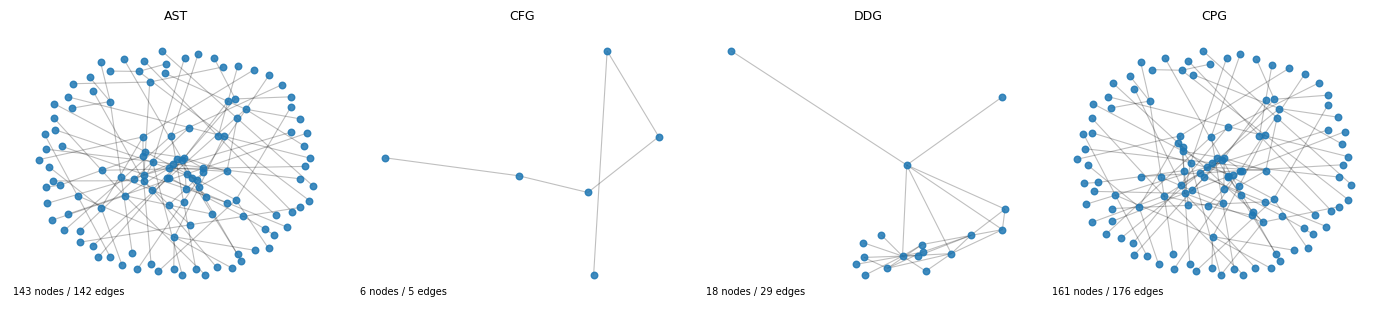

,method_id,graph_type,status,nodes,edges,ast_nodes,code_lines,code_chars,suspicious_limit
87,30201,cfg,suspicious_small,10,10,111,15,529,11


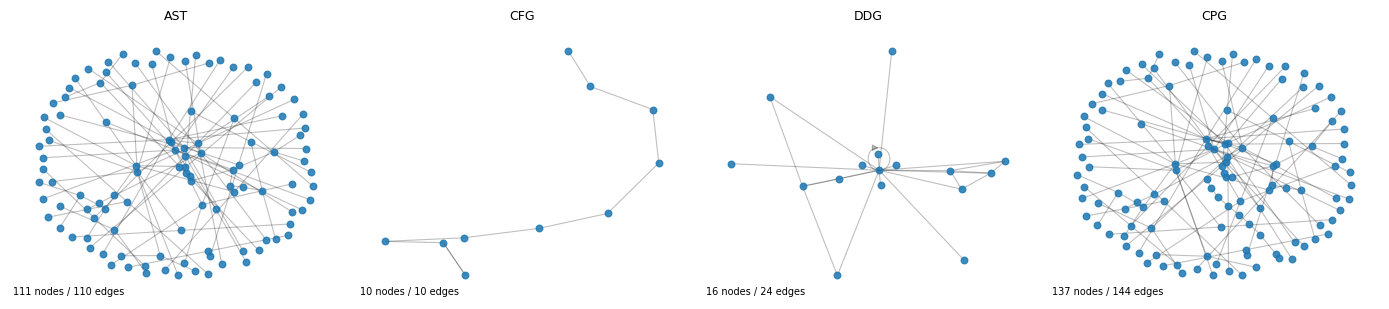

In [27]:
manifest = load_graph_manifest()
print("Graph methods:", manifest.get("total_methods"))

SMALL_NODE_LIMIT = 6
SUSPICIOUS_MIN_CODE_LINES = 8
SUSPICIOUS_LINE_RATIO = 0.75
MAX_EXAMPLES = 8


def load_code_stats(path: Path) -> dict[str, dict[str, int]]:
    stats = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            code = row.get("func", "")
            method_id = str(row["idx"])
            stats[method_id] = {
                "code_lines": sum(1 for item in code.splitlines() if item.strip()),
                "code_chars": len(code),
            }
    return stats


def suspicious_limit_for(graph_type: str, code_lines: int) -> int:
    if graph_type not in {"cfg", "ddg"}:
        return SMALL_NODE_LIMIT
    return max(SMALL_NODE_LIMIT, int(min(code_lines, 40) * SUSPICIOUS_LINE_RATIO))


code_stats = load_code_stats(DATA_DIR / "data.jsonl")
rows = []
example_scores = {}
all_method_ids = set()
for shard_path in manifest.get("shards", []):
    with Path(shard_path).open("rb") as f:
        shard = pickle.load(f)
    for method_id, layers in shard.items():
        method_id = str(method_id)
        all_method_ids.add(method_id)
        stats = code_stats.get(method_id, {"code_lines": 0, "code_chars": 0})
        code_lines = int(stats["code_lines"])
        code_chars = int(stats["code_chars"])
        ast_graph = layers.get("ast")
        ast_nodes = 0 if ast_graph is None else ast_graph.number_of_nodes()
        for graph_type in GRAPH_TYPES:
            graph = layers.get(graph_type)
            if graph is None:
                status = "missing"
                nodes = 0
                edges = 0
            else:
                nodes = graph.number_of_nodes()
                edges = graph.number_of_edges()
                if nodes == 0:
                    status = "empty"
                elif (
                    graph_type in {"cfg", "ddg"}
                    and code_lines >= SUSPICIOUS_MIN_CODE_LINES
                    and ast_nodes >= 50
                    and nodes <= suspicious_limit_for(graph_type, code_lines)
                ):
                    status = "suspicious_small"
                elif nodes <= SMALL_NODE_LIMIT:
                    status = "small_nonempty"
                else:
                    status = "ok"
            if status in {"missing", "empty", "small_nonempty", "suspicious_small"}:
                rows.append({
                    "method_id": method_id,
                    "graph_type": graph_type,
                    "status": status,
                    "nodes": int(nodes),
                    "edges": int(edges),
                    "ast_nodes": int(ast_nodes),
                    "code_lines": code_lines,
                    "code_chars": code_chars,
                    "suspicious_limit": suspicious_limit_for(graph_type, code_lines),
                })
                score = 3 if status == "suspicious_small" else 2 if status in {"missing", "empty"} else 1
                example_scores[method_id] = max(example_scores.get(method_id, 0), score)

small_df = pd.DataFrame(rows)
summary_df = (
    small_df.groupby(["graph_type", "status"])
    .agg(
        layers=("method_id", "count"),
        unique_methods=("method_id", "nunique"),
        avg_nodes=("nodes", "mean"),
        avg_edges=("edges", "mean"),
        avg_code_lines=("code_lines", "mean"),
        avg_ast_nodes=("ast_nodes", "mean"),
    )
    .reset_index()
    if not small_df.empty else pd.DataFrame(columns=["graph_type", "status", "layers", "unique_methods", "avg_nodes", "avg_edges", "avg_code_lines", "avg_ast_nodes"])
)
summary_df["total_methods"] = len(all_method_ids)
summary_df["unique_method_fraction"] = summary_df["unique_methods"] / max(1, len(all_method_ids))

display(summary_df.sort_values(["graph_type", "status"]))
if not small_df.empty:
    display(small_df.sort_values(["status", "graph_type", "code_lines", "nodes"], ascending=[True, True, False, True]).head(80))
else:
    display(small_df)

if (OUTPUT_ROOT / "timing_stats.json").exists():
    timing_stats = json.loads((OUTPUT_ROOT / "timing_stats.json").read_text(encoding="utf-8"))
    timing_keys = [key for key in timing_stats if "fallback" in key or "dot_missing" in key or key in {"total_methods", "skipped_graph_layers_pipeline01"}]
    display(pd.DataFrame([{"metric": key, "value": timing_stats[key]} for key in sorted(timing_keys)]))

ranked = sorted(example_scores.items(), key=lambda item: item[1], reverse=True)
example_method_ids = [method_id for method_id, _ in ranked[:MAX_EXAMPLES]]
if not example_method_ids and not small_df.empty:
    example_method_ids = small_df[small_df["status"] != "missing"]["method_id"].drop_duplicates().head(MAX_EXAMPLES).tolist()
print("Example method ids:", example_method_ids)
print("Suspicious small CFG/DDG layers are code-size-aware; missing layers are reported separately.")

code_map = load_code_for_ids(DATA_DIR / "data.jsonl", set(example_method_ids))
graph_map = load_graphs_for_ids(manifest, set(example_method_ids))
print("Loaded examples:", len(code_map), len(graph_map))

for method_id in example_method_ids:
    render_code(method_id, code_map, f"Suspicious/missing graph method {method_id}")
    display(small_df[small_df["method_id"] == method_id].sort_values(["status", "graph_type"]))
    fig, axes = plt.subplots(1, len(GRAPH_TYPES), figsize=(3.5 * len(GRAPH_TYPES), 3.2), squeeze=False)
    for ax, graph_type in zip(axes[0], GRAPH_TYPES):
        draw_graph(graph_map.get(method_id, {}).get(graph_type), graph_type.upper(), ax, max_nodes=120)
    plt.tight_layout()
    plt.show()